In [31]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
train_df = pd.read_csv('train_sales.csv', parse_dates=['Date'], low_memory=False)
test_df = pd.read_csv('test.csv', parse_dates=['Date'], low_memory=False)
store_df = pd.read_csv('store.csv', low_memory=False)

In [33]:
train_df = train_df[(train_df['Open'] != 0) & (train_df['Sales'] > 0)]

In [34]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [35]:
test_df.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [36]:
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [37]:
print("Merging store details & engineering features...")
train_df = pd.merge(train_df, store_df, on='Store', how='left')
test_df = pd.merge(test_df, store_df, on='Store', how='left')

Merging store details & engineering features...


In [38]:
print(store_df.isnull().sum())


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [48]:
def extract_features(df):
  df = df.copy()

  # Temporal / Date Features
  df['Year'] = df['Date'].dt.year
  df['Month'] = df['Date'].dt.month
  df['Day'] = df['Date'].dt.day
  df['DayOfWeek'] = df['Date'].dt.dayofweek
  df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
  df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

  # Handle Missing Competition Values
  df['CompetitionDistance'] = df['CompetitionDistance'].fillna(
      df['CompetitionDistance'].median()
  )
  df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(2000)
  df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(1)

  # Calculate Active Competition Duration in Months
  df['CompetitionOpenMonths'] = 12 * (
      df['Year'] - df['CompetitionOpenSinceYear']
  ) + (df['Month'] - df['CompetitionOpenSinceMonth'])
  df['CompetitionOpenMonths'] = df['CompetitionOpenMonths'].apply(
      lambda x: x if x > 0 else 0
  )
    # Encoding Categorical Variables
  mappings = {
      'StateHoliday': {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3},
      'StoreType': {'a': 1, 'b': 2, 'c': 3, 'd': 4},
      'Assortment': {'a': 1, 'b': 2, 'c': 3},
  }
  for col, mapping in mappings.items():
    df[col] = df[col].map(mapping).fillna(0).astype(int)

  if 'Open' in df.columns:
    df['Open'] = df['Open'].fillna(1)

  return df

In [50]:
train_processed = extract_features(train_df)
test_processed = extract_features(test_df)

In [51]:
train_processed['Log_Sales'] = np.log1p(train_processed['Sales'])

feature_cols = [
    'Store',
    'DayOfWeek',
    'Promo',
    'StateHoliday',
    'SchoolHoliday',
    'StoreType',
    'Assortment',
    'CompetitionDistance',
    'CompetitionOpenMonths',
    'Promo2',
    'Year',
    'Month',
    'Day',
    'WeekOfYear',
    'IsWeekend',
]

In [52]:
# Last 6 weeks (42 days) of training data used for realistic validation
train_processed = train_processed.sort_values('Date')
cutoff_date = train_processed['Date'].max() - pd.Timedelta(days=42)

X_train = train_processed[train_processed['Date'] <= cutoff_date][feature_cols]
y_train = train_processed[train_processed['Date'] <= cutoff_date]['Log_Sales']

X_val = train_processed[train_processed['Date'] > cutoff_date][feature_cols]
y_val = train_processed[train_processed['Date'] > cutoff_date]['Log_Sales']
y_val_actual = train_processed[train_processed['Date'] > cutoff_date]['Sales']

print(
    f"Training Records: {len(X_train):,} | Validation Records:"
    f" {len(X_val):,}"
)



Training Records: 804,056 | Validation Records: 40,282


In [53]:
# MODEL TRAINING (XGBoost Regressor)
print("Training XGBoost Regressor...")
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

Training XGBoost Regressor...
[0]	validation_0-rmse:0.41118
[100]	validation_0-rmse:0.26687
[200]	validation_0-rmse:0.20896
[300]	validation_0-rmse:0.18005
[400]	validation_0-rmse:0.16160
[500]	validation_0-rmse:0.15027
[600]	validation_0-rmse:0.14318
[700]	validation_0-rmse:0.13824
[800]	validation_0-rmse:0.13513
[900]	validation_0-rmse:0.13255
[999]	validation_0-rmse:0.13051


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [54]:
#  MODEL EVALUATION & METRICS
val_preds_log = model.predict(X_val)
val_preds = np.expm1(val_preds_log)  # Reverse log1p transform



In [55]:
def compute_rmspe(y_true, y_pred):
  return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2)) * 100


In [56]:
mae = mean_absolute_error(y_val_actual, val_preds)
rmse = np.sqrt(mean_squared_error(y_val_actual, val_preds))
r2 = r2_score(y_val_actual, val_preds)
rmspe = compute_rmspe(y_val_actual.values, val_preds)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"RMSPE: {rmspe:.2f}%")


Mean Absolute Error (MAE): 680.76
Root Mean Squared Error (RMSE): 1007.95
R² Score: 0.8911
RMSPE: 13.95%


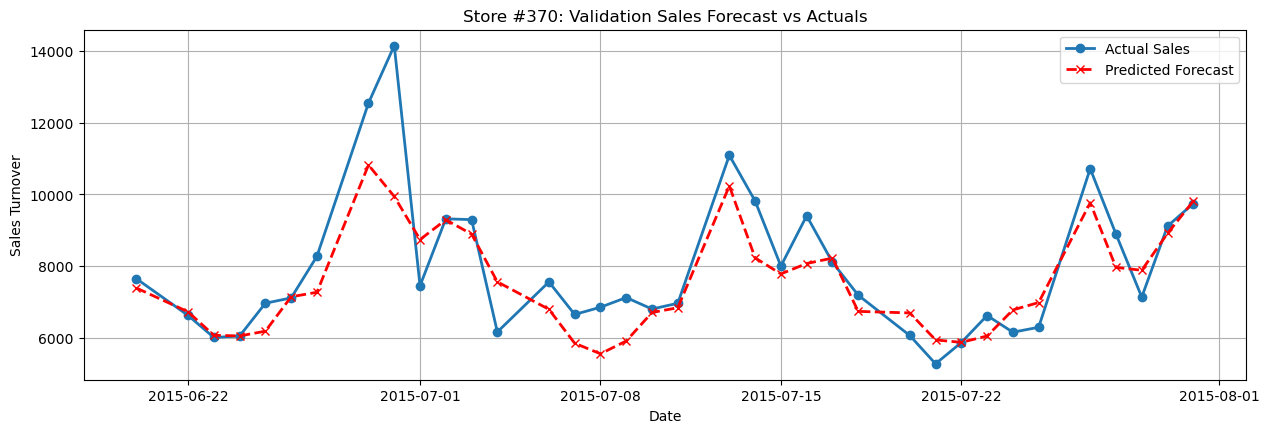

In [59]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
sample_store_id = train_processed[train_processed['Date'] > cutoff_date][
    'Store'
].iloc[0]
mask = (train_processed['Date'] > cutoff_date) & (
    train_processed['Store'] == sample_store_id
)
sample_dates = train_processed[mask]['Date']
sample_actual = train_processed[mask]['Sales']
sample_pred = val_preds[
    train_processed[train_processed['Date'] > cutoff_date]['Store']
    == sample_store_id
]
plt.plot(
    sample_dates,
    sample_actual,
    label='Actual Sales',
    marker='o',
    linewidth=2,
)
plt.plot(
    sample_dates,
    sample_pred,
    label='Predicted Forecast',
    linestyle='--',
    marker='x',
    color='red',
    linewidth=2,
)
plt.title(f'Store #{sample_store_id}: Validation Sales Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Sales Turnover')
plt.legend()
plt.grid(True)


C:\Users\ny266\AppData\Local\Temp\ipykernel_11716\3693340697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


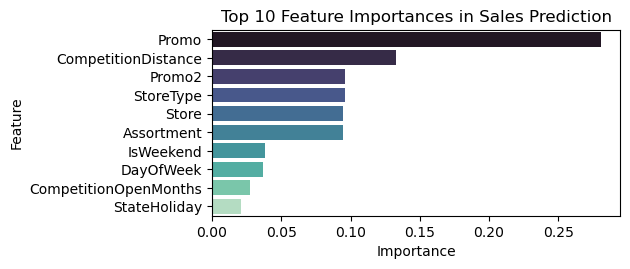

In [60]:
plt.subplot(2, 1, 2)
imp_df = pd.DataFrame(
    {'Feature': feature_cols, 'Importance': model.feature_importances_}
).sort_values('Importance', ascending=False)
sns.barplot(
    x='Importance', y='Feature', data=imp_df.head(10), palette='mako'
)
plt.title('Top 10 Feature Importances in Sales Prediction')
plt.tight_layout()
plt.show()

In [61]:
print("\nGenerating final test set forecasts...")
X_test = test_processed[feature_cols]
test_preds_log = model.predict(X_test)
test_preds = np.expm1(test_preds_log)



Generating final test set forecasts...


In [62]:
test_preds = np.where(test_processed['Open'] == 0, 0, test_preds)

submission = pd.DataFrame({'Id': test_df['Id'], 'Sales': test_preds})

submission.to_csv('submission.csv', index=False)
print("Saved final predictions to 'submission.csv'!")

Saved final predictions to 'submission.csv'!


In [64]:
import joblib

model_data = {
    'model': model,
    'feature_cols': feature_cols,
}
joblib.dump(model_data, 'rossmann_xgb_model.pkl')
print('Model saved successfully as rossmann_xgb_model.pkl!')

Model saved successfully as rossmann_xgb_model.pkl!


In [68]:
file_path = os.path.abspath('rossmann_xgb_model.pkl')
file_path

'C:\\Users\\ny266\\rossmann_xgb_model.pkl'